# The Text2CAD 2026

## Constants

In [1]:
BATCH_SIZE = 32
MAX_NEW_CMDS = 64
EPOCHS = 100
SAMPLE_RATIO = 0.01

## Imports

In [2]:
from dotenv import load_dotenv
load_dotenv(".env")

from tqdm import tqdm
import random
import os

In [3]:
import torch

path = "data/text2cad/cad_seq/0040/00406195/seq/00406195.pth"
obj = torch.load(path, map_location="cpu")

print(type(obj))
print(obj.keys())

<class 'dict'>
dict_keys(['vec', 'mask_cad_dict'])


## Loader Validator

### Load in CAD JSON in Text2CADLoader

In [4]:
from utils.dataset.text2cad import Text2CADLoader

loader = Text2CADLoader(
    data_root="data/text2cad"
)
    

In [5]:
result = loader.load()
result.head(2)

Loading CSV from: /home/alief/prjkcad/data/text2cad/text2cad_v1.1.csv
Processing 176017 rows to load JSON payloads...


Loading Text2CAD JSONs: 100%|██████████| 176017/176017 [01:22<00:00, 2130.02it/s]


,uid,abstract,beginner,expert,description,keywords,intermediate,all_level_data,nli_data,json_target
0,0035/00359148,A rectangular block with a flat top and bottom...,The design involves creating a small rectangul...,Start by creating a new coordinate system with...,A rectangular block with a flat top and bottom...,"['rectangular', 'block', 'flat top', 'flat bot...",Create a rectangular block by starting with a ...,<level1>\nStart by creating a new coordinate s...,<part_1>\n### Construct a Rectangular Block\n#...,"{'final_name': '', 'final_shape': '', 'parts':..."
1,0035/00354394,A cylindrical object with a rectangular sectio...,The design features a thin rectangular block. ...,Start by creating a new coordinate system with...,A cylindrical object with a rectangular sectio...,"['Cylinder', 'Rectangular Section', 'Top']",The design involves creating a rectangular sec...,<level1>\nStart by creating a new coordinate s...,<part_1>\n### Construct a Rectangular Section\...,"{'final_name': '', 'final_shape': '', 'parts':..."


### Try to load CAD JSON in DualSeq representation

In [6]:
from utils.dual_seq import DualSeq
from typing import List

success_count = 0
part_counts = {}
failed_indices = []
extrusion_kinds = {}
dual_seqs: List[DualSeq] = []
for i, row in tqdm(result.iterrows(), total=len(result)):
    try :
        json_object = row["json_target"]
        descriptions = {
            "abstract": row["abstract"],
            "beginner": row["beginner"],
            "intermediate": row["intermediate"],
            "expert": row["expert"],
        }
        dual_seq = DualSeq(json_object,
                           uid=row["uid"],
                           descriptions=descriptions)
        success_count += 1
        dual_seqs.append(dual_seq)

        for extrusion in dual_seq.extrusion_kinds:
            if extrusion not in extrusion_kinds:
                extrusion_kinds[extrusion] = 0
            extrusion_kinds[extrusion] += 1
        
        if dual_seq.part_count > 1:
            part_counts[dual_seq.uid] = dual_seq.part_count
    except Exception as e:
        failed_indices.append(row["uid"])
        print(f"Error at index {i}: {e}")
        break
        
print(f"Successfully converted {success_count} out of {len(result)} JSON objects to DualSeq.")
print(f"Number of entities with more than 1 part: {len(part_counts)}")
print(f"Indices of entities with more than 1 part: {list(part_counts.keys())[:10]}")

print(f"Example failed indices: {failed_indices[:10]}")

100%|██████████| 176017/176017 [00:11<00:00, 14875.41it/s]

Successfully converted 176017 out of 176017 JSON objects to DualSeq.
Number of entities with more than 1 part: 56241
Indices of entities with more than 1 part: ['0035/00351935', '0035/00351992', '0035/00350305', '0035/00353599', '0035/00351586', '0035/00356953', '0035/00350529', '0035/00350372', '0035/00356962', '0035/00351387']
Example failed indices: []


In [7]:
print("Example entity")
print(dual_seqs[0])

Example entity
cmd         | args                                                                                                  
------------+-------------------------------------------------------------------------------------------------------
COOR        | {'coor_euax': 0.0, 'coor_euay': 0.0, 'coor_euaz': 0.0, 'coor_tx': 0.0, 'coor_ty': 0.0, 'coor_tz': 0.0}
FACE        | {}                                                                                                    
LOOP        | {}                                                                                                    
LINE        | {'line_sx': 0.0, 'line_sy': 0.0, 'line_ex': 0.6, 'line_ey': 0.0}                                      
LINE        | {'line_sx': 0.6, 'line_sy': 0.0, 'line_ex': 0.6, 'line_ey': 0.375}                                    
LINE        | {'line_sx': 0.6, 'line_sy': 0.375, 'line_ex': 0.0, 'line_ey': 0.375}                                  
LINE        | {'line_sx': 0.0, 'line_sy': 0.375, 

In [8]:
cmd_counts = {}
arg_counts = {}
for dual_seq in tqdm(dual_seqs, total=len(dual_seqs)):
    for cmd in dual_seq.cmds:
        if cmd not in cmd_counts:
            cmd_counts[cmd] = 0
        cmd_counts[cmd] += 1
    
    for arg in dual_seq.args:
        for arg_name in arg:
            if arg_name not in arg_counts:
                arg_counts[arg_name] = 0
            arg_counts[arg_name] += 1

print(f"Extrusion kinds: {extrusion_kinds}")
print(f"Unique commands: {len(cmd_counts)}")
print(f"Unique arguments: {len(arg_counts)}")
print(f"Command counts: {cmd_counts}")
print(f"Argument counts: {arg_counts}")

  0%|          | 0/176017 [00:00<?, ?it/s]

100%|██████████| 176017/176017 [00:01<00:00, 141515.88it/s]

Extrusion kinds: {'NewBodyFeatureOperation': 175990, 'JoinFeatureOperation': 30993, 'CutFeatureOperation': 24707, 'IntersectFeatureOperation': 128}
Unique commands: 9
Unique arguments: 25
Command counts: {'COOR': 267971, 'FACE': 360387, 'LOOP': 463332, 'LINE': 1159880, 'EXTRUDE_NEW': 190177, 'CIRCLE': 189135, 'EXTRUDE_JOIN': 41978, 'EXTRUDE_CUT': 35669, 'EXTRUDE_INTERSECT': 147}
Argument counts: {'coor_euax': 267971, 'coor_euay': 267971, 'coor_euaz': 267971, 'coor_tx': 267971, 'coor_ty': 267971, 'coor_tz': 267971, 'line_sx': 1159880, 'line_sy': 1159880, 'line_ex': 1159880, 'line_ey': 1159880, 'extrude_new_dtn': 190177, 'extrude_new_don': 190177, 'extrude_new_scale': 190177, 'circle_cx': 189135, 'circle_cy': 189135, 'circle_r': 189135, 'extrude_join_dtn': 41978, 'extrude_join_don': 41978, 'extrude_join_scale': 41978, 'extrude_cut_dtn': 35669, 'extrude_cut_don': 35669, 'extrude_cut_scale': 35669, 'extrude_intersect_dtn': 147, 'extrude_intersect_don': 147, 'extrude_intersect_scale': 147}


In [9]:
import pandas as pd

param_columns = list(arg_counts.keys())

all_rows = []

for ds in tqdm(dual_seqs, total=len(dual_seqs)):
    for cmd_type, params in zip(ds.cmds, ds.args):
        row = {"cmd_type": cmd_type}
        row.update({col: params.get(col) for col in param_columns})
        all_rows.append(row)

final_df = pd.DataFrame(all_rows, columns=["cmd_type"] + param_columns)

print(final_df.head())

  0%|          | 0/176017 [00:00<?, ?it/s]

100%|██████████| 176017/176017 [00:05<00:00, 32683.83it/s]


  cmd_type  coor_euax  coor_euay  coor_euaz  coor_tx  coor_ty  coor_tz  \
0     COOR        0.0        0.0        0.0      0.0      0.0      0.0   
1     FACE        NaN        NaN        NaN      NaN      NaN      NaN   
2     LOOP        NaN        NaN        NaN      NaN      NaN      NaN   
3     LINE        NaN        NaN        NaN      NaN      NaN      NaN   
4     LINE        NaN        NaN        NaN      NaN      NaN      NaN   

   line_sx  line_sy  line_ex  ...  circle_r  extrude_join_dtn  \
0      NaN      NaN      NaN  ...       NaN               NaN   
1      NaN      NaN      NaN  ...       NaN               NaN   
2      NaN      NaN      NaN  ...       NaN               NaN   
3      0.0      0.0      0.6  ...       NaN               NaN   
4      0.6      0.0      0.6  ...       NaN               NaN   

   extrude_join_don  extrude_join_scale  extrude_cut_dtn  extrude_cut_don  \
0               NaN                 NaN              NaN              NaN   
1         

In [10]:
final_df.nunique(dropna=False)

cmd_type                      9
coor_euax                   188
coor_euay                   115
coor_euaz                   196
coor_tx                    7724
coor_ty                    7926
coor_tz                    7062
line_sx                    8336
line_sy                    8068
line_ex                    8339
line_ey                    8065
extrude_new_dtn            7221
extrude_new_don            3190
extrude_new_scale          7946
circle_cx                  7190
circle_cy                  6888
circle_r                   3835
extrude_join_dtn           4619
extrude_join_don           2106
extrude_join_scale         6592
extrude_cut_dtn            1864
extrude_cut_don            4842
extrude_cut_scale          6722
extrude_intersect_dtn        60
extrude_intersect_don        58
extrude_intersect_scale      59
dtype: int64

## Experiment 1A : T5EncT5DecCAD Initial Training

### Initiate T5

In [14]:
# initiate pretrained parts
from transformers import T5Tokenizer, T5ForConditionalGeneration
t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")
t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")
t5_encoder = t5_model.encoder
t5_decoder = t5_model.decoder

print(f"Encoder layers: {len(t5_encoder.block)}")
print(f"Decoder layers: {len(t5_decoder.block)}")

print(f"Encoder hidden size: {t5_encoder.config.hidden_size}")
print(f"Decoder hidden size: {t5_decoder.config.hidden_size}")

print(f"Encoder vocab size: {t5_encoder.config.vocab_size}")
print(f"Decoder vocab size: {t5_decoder.config.vocab_size}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Encoder layers: 6
Decoder layers: 6
Encoder hidden size: 512
Decoder hidden size: 512
Encoder vocab size: 32128
Decoder vocab size: 32128


### Example from t5

In [15]:
t5_example_out = t5_model(input_ids=torch.tensor([[1, 2, 3]]), decoder_input_ids=torch.tensor([[1, 2, 3]]))
print(f"Example : {t5_example_out}")

Example : Seq2SeqLMOutput(loss=None, logits=tensor([[[-36.6730,  -9.4912, -14.5714,  ..., -60.2639, -60.3260, -60.2650],
         [-31.3614,  -7.1717, -13.0354,  ..., -54.9488, -55.0022, -54.9456],
         [-26.5839, -10.5030,  -1.8764,  ..., -49.4160, -49.3938, -49.3363]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=EncoderDecoderCache(self_attention_cache=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), cross_attention_cache=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer])), decoder_hidden_states=None, decoder_attentions=None, cross_attentions=None, encoder_last_hidden_state=tensor([[[ 0.0118,  0.0274, -0.0088,  ...,  0.0276,  0.0543,  0.0438],
         [-0.1139, -0.0016,  0.0641,  ...,  0.0419,  0.0208,  0.1420],
         [-0.1679,  0.1921, -0.1541,  ...,  0.0620, -0.1354,  0.0304]]],
       grad_fn=<MulBackward0>), encoder_hidden_states=None, encoder_atten

### Data Preprocessing

In [16]:
from utils.data_utils import create_cmdonly_data_loader, DualSeqCmdonlyDataset

k = int(SAMPLE_RATIO * len(dual_seqs))
sample_dual_seqs = random.sample(dual_seqs, k)

cmdonly_loader = create_cmdonly_data_loader(
    dual_seqs=sample_dual_seqs,
    description_tokenizer=t5_tokenizer,
    description_level="abstract",
    batch_size=BATCH_SIZE,
    num_workers=4,
)

print(f"Number of batches: {len(cmdonly_loader)}")
example_batch = next(iter(cmdonly_loader)) # X, y, attn_mask
print(f"Example description tokens shape: {example_batch[0].shape}")
print(f"Example command tokens shape: {example_batch[1].shape}")
print(f"Example attention mask shape: {example_batch[2].shape}")

print(f"Example description tokens: {example_batch[0][0][:10]}")
print(f"Example command tokens: {example_batch[1][0][:10]}")
print(f"Example attention mask: {example_batch[2][0][:10]}")

Number of batches: 55
Example description tokens shape: torch.Size([32, 55])
Example command tokens shape: torch.Size([32, 62])
Example attention mask shape: torch.Size([32, 55])
Example description tokens: tensor([   71, 24675,  3735,    28,     3,     9, 31881,  1247,    11,     3])
Example command tokens: tensor([1, 2, 3, 4, 5, 5, 5, 5, 7, 2])
Example attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [17]:
# main model
from models import T5EncT5DecCAD
from utils.dual_seq import DEFAULT_COMMANDS 
model = T5EncT5DecCAD(
    t5_encoder,
    t5_decoder,
    len(DEFAULT_COMMANDS),
    max_new_cmds=MAX_NEW_CMDS,
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")
print(model)

Model parameters: 60550667
T5EncT5DecCAD(
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Dropout(p=0.1, inplace=F

In [18]:
# Test model
test_desc, cmds, attn_mask = example_batch

print(f"Description shape: {test_desc.shape}")
print(f"Attention mask shape: {attn_mask.shape}")
print(f"Commands shape: {cmds.shape}")

logits0, dec_out, enc_emb = model(test_desc, attn_mask)
print(f"First output shape: {logits0.shape}")
cmd0 = torch.argmax(logits0, dim=-1)
print(f"Predicted command tokens shape: {cmd0.shape}")

logits1, dec_out, _ = model(test_desc, attn_mask, decoder_input_ids=cmd0, decoder_out_embeddings=dec_out, encoder_out_embeddings=enc_emb)
print(f"Second output shape: {logits1.shape}")
print(f"Second decoder output shape: {dec_out.shape}")

Description shape: torch.Size([32, 55])
Attention mask shape: torch.Size([32, 55])
Commands shape: torch.Size([32, 62])
First output shape: torch.Size([32, 1, 11])
Predicted command tokens shape: torch.Size([32, 1])
Second output shape: torch.Size([32, 1, 11])
Second decoder output shape: torch.Size([32, 1, 512])


In [19]:
# Test model with 10 first new tokens
with torch.no_grad():
    test_desc, cmds, attn_mask = example_batch
    logits0, dec_out, enc_emb = model(test_desc, attn_mask)
    cmd0 = torch.argmax(logits0, dim=-1)
    logits1, dec_out, _ = model(test_desc, attn_mask, decoder_input_ids=cmd0[:, :10], decoder_out_embeddings=dec_out, encoder_out_embeddings=enc_emb)
    
    results = [cmd0]
    for i in range(10) :
        logits, dec_out, _ = model(test_desc, attn_mask, decoder_input_ids=results[-1], decoder_out_embeddings=dec_out, encoder_out_embeddings=enc_emb)
        next_cmd = torch.argmax(logits, dim=-1)
        results.append(next_cmd)

merged_cmds = torch.cat(results, dim=1)
print(f"Merged predicted command tokens shape: {merged_cmds.shape}")
for i in range(5) :
    print(f"Predicted command tokens for sample {i}: {merged_cmds[i][:20]}")

Merged predicted command tokens shape: torch.Size([32, 11])
Predicted command tokens for sample 0: tensor([3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
Predicted command tokens for sample 1: tensor([3, 4, 2, 5, 2, 2, 2, 2, 2, 2, 2])
Predicted command tokens for sample 2: tensor([2, 2, 5, 5, 5, 5, 5, 2, 2, 2, 2])
Predicted command tokens for sample 3: tensor([2, 2, 2, 2, 5, 2, 5, 5, 5, 5, 2])
Predicted command tokens for sample 4: tensor([3, 2, 4, 2, 5, 2, 5, 2, 5, 2, 5])


### Training

In [20]:
from utils.trainer import DualSeqCMDOnlyTrainer
from utils.criterion import DualSeqCMDOnlyCriterion
from utils.wrapper import DualSeqCMDOnlyWrapper

criterion = DualSeqCMDOnlyCriterion()
wrapper = DualSeqCMDOnlyWrapper(model, text_tokenizer=t5_tokenizer) # use default device
trainer = DualSeqCMDOnlyTrainer(
    model_wrapper=wrapper,
    train_loader=cmdonly_loader,
    val_loader=cmdonly_loader, # using train loader for eval just for testing
    optimizer=torch.optim.Adam(wrapper.model.parameters(), lr=1e-4),
    criterion=criterion,
    max_new_cmds=25, # max number for initial training
)

history = trainer.train(epochs=EPOCHS)

Eval 1/100: 100%|██████████| 55/55 [01:01<00:00,  1.12s/it]


Epoch 1/100: {'train_loss': 2.0220639445564963, 'val_loss': 1.714638031612743, 'val_perplexity': 5.568622948652721, 'val_accuracy': 0.15676452856172216}


Eval 2/100: 100%|██████████| 55/55 [00:59<00:00,  1.08s/it]


Epoch 2/100: {'train_loss': 1.631571288542314, 'val_loss': 1.4400031609968706, 'val_perplexity': 4.232126254337799, 'val_accuracy': 0.17805378938263114}


Eval 3/100: 100%|██████████| 55/55 [01:02<00:00,  1.14s/it]


...

Epoch 98/100: {'train_loss': 0.6953800022602081, 'val_loss': 0.6360859870910645, 'val_perplexity': 1.8998549067441137, 'val_accuracy': 0.26096120341257617}


Eval 99/100: 100%|██████████| 55/55 [01:01<00:00,  1.13s/it]


Epoch 99/100: {'train_loss': 0.700940512527119, 'val_loss': 0.6725067192857915, 'val_perplexity': 1.9747421181307816, 'val_accuracy': 0.26301603994586253}


Eval 100/100: 100%|██████████| 55/55 [01:04<00:00,  1.18s/it]

Epoch 100/100: {'train_loss': 0.7075046057050879, 'val_loss': 0.6350803759965029, 'val_perplexity': 1.8970259881370533, 'val_accuracy': 0.27193956754424353}


### Plot

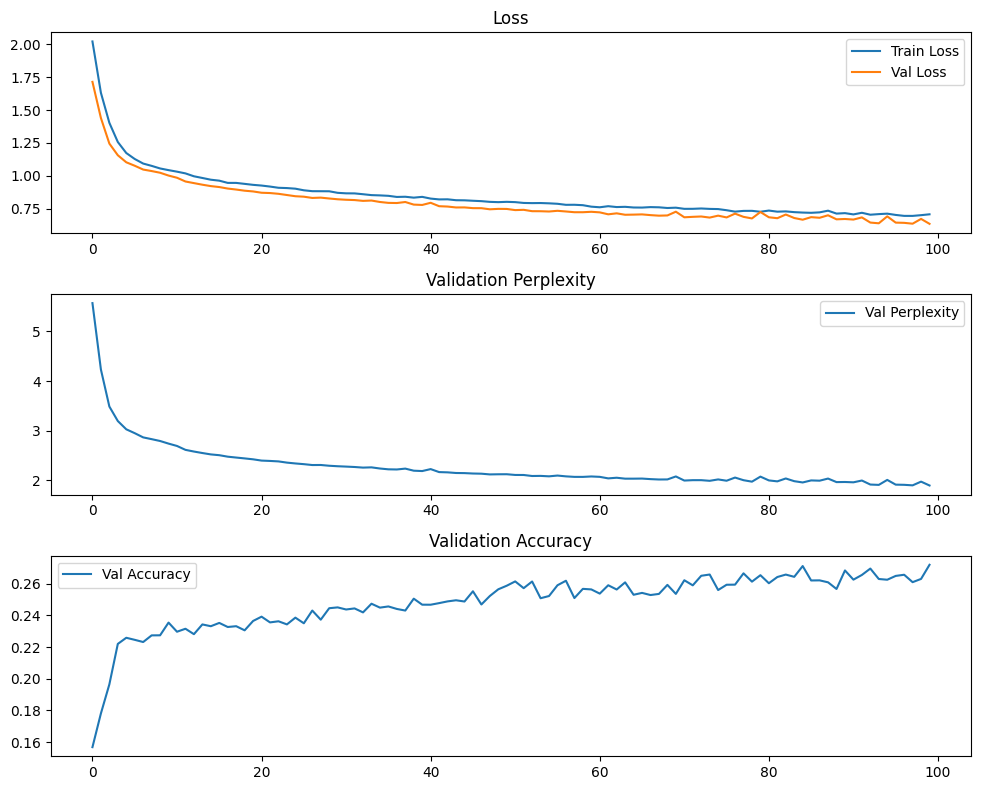

In [21]:
import matplotlib.pyplot as plt

viz_keys = {
    "loss" : {
        "train": [h["train_loss"] for h in history],
        "val": [h["val_loss"] for h in history],
    },
    "val_perplexity" : {
        "val": [h["val_perplexity"] for h in history],
    },
    "val_accuracy" : {
        "val": [h["val_accuracy"] for h in history],
    },
}

fig, ax = plt.subplots(3, 1, figsize=(10, 8))

ax[0].plot(viz_keys["loss"]["train"], label="Train Loss")
ax[0].plot(viz_keys["loss"]["val"], label="Val Loss")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(viz_keys["val_perplexity"]["val"], label="Val Perplexity")
ax[1].set_title("Validation Perplexity")
ax[1].legend()

ax[2].plot(viz_keys["val_accuracy"]["val"], label="Val Accuracy")
ax[2].set_title("Validation Accuracy")
ax[2].legend()

plt.tight_layout()
plt.show()


### Test Inference

In [27]:
wrapper = trainer.wrapper
inference_results = []


for ds in tqdm(sample_dual_seqs[:BATCH_SIZE * 2], total=BATCH_SIZE * 2):
    desc_text = ds.descriptions["abstract"]
    commands = wrapper.generate(desc_text)
    ground_truth = ds.cmds
    inference_results.append({"text": desc_text, "commands": commands, "ground_truth": ground_truth})

df_inference = pd.DataFrame(inference_results)
df_inference.head()

100%|██████████| 64/64 [01:10<00:00,  1.10s/it]


,text,commands,ground_truth
0,"The object is a straight, vertical rod with a ...","[COOR, FACE, LOOP, LINE, LINE, LINE, LINE, EXT...","[COOR, FACE, LOOP, LINE, LINE, LINE, LINE, EXT..."
1,A cylinder with a small cylindrical protrusion...,"[COOR, FACE, LOOP, CIRCLE, EXTRUDE_NEW, CIRCLE...","[COOR, FACE, LOOP, CIRCLE, FACE, LOOP, CIRCLE,..."
2,The object is a flat washer with a central hol...,"[COOR, FACE, LOOP, CIRCLE, LOOP, CIRCLE, EXTRU...","[COOR, FACE, LOOP, CIRCLE, LOOP, CIRCLE, EXTRU..."
3,A cone with a flat circular base and a pointed...,"[COOR, FACE, LOOP, CIRCLE, EXTRUDE_NEW, COOR, ...","[COOR, FACE, LOOP, CIRCLE, EXTRUDE_NEW, COOR, ..."
4,A rectangular block with rounded edges and a f...,"[COOR, FACE, LOOP, LINE, LINE, LINE, LINE, EXT...","[COOR, FACE, LOOP, LINE, LINE, LINE, LINE, EXT..."


In [28]:
os.makedirs("out/test_results", exist_ok=True)
df_inference.to_csv("out/test_results/exp1_dual_seq_cmdonly.csv", index=False)

### Test Save

In [24]:
wrapper.save("out/checkpoints/exp1_dual_seq_cmdonly")

### Test Load

In [25]:
from utils.wrapper.dual_seq_cmdonly import DualSeqCMDOnlyWrapper
wrapper = DualSeqCMDOnlyWrapper.from_pretrained("out/checkpoints/exp1_dual_seq_cmdonly", "t5-small", model_config={"max_new_cmds": 64})

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model loaded from out/checkpoints/exp1_dual_seq_cmdonly


In [26]:
# Test inference after load
test_desc = "Create a box with width 10, height 20, and depth 30."
generated_cmds = wrapper.generate(test_desc)
print(f"Generated commands for test description: {generated_cmds}")

Generated commands for test description: ['COOR', 'FACE', 'LOOP', 'LINE', 'LINE', 'LINE', 'LINE', 'EXTRUDE_NEW', 'LINE', 'FACE', 'LOOP', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE', 'LINE']


## Experiment1B : T5EncT5DecCAD Full Training

### Reload Initial T5

In [29]:
from utils.wrapper import DualSeqCMDOnlyWrapper
wrapper = DualSeqCMDOnlyWrapper.from_pretrained("out/checkpoints/exp1_dual_seq_cmdonly", "t5-small", model_config={"max_new_cmds": 64})

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model loaded from out/checkpoints/exp1_dual_seq_cmdonly


In [31]:
# extend positional embeddingto 256
model = wrapper.model
side_pos_emb = model.side_embedding.pos_embedding
print(f"Original positional embedding shape: {side_pos_emb.weight.shape}")

Original positional embedding shape: torch.Size([64, 512])


# Cleaners

## GC

In [ ]:
import gc
gc.collect()
import torch
torch.cuda.empty_cache()